# 03 — EDA: Bivariate & Multivariate Analysis
How do features relate to the target variable `y`, and to each other?

In [1]:
import sys, warnings
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import RAW_DIR, TARGET_COL
from src.data_loader import load_dataset
from src.features import encode_target, add_features

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

df_raw = load_dataset(RAW_DIR / "bank-additional-full.csv")
df = encode_target(df_raw.copy(), TARGET_COL)
df = add_features(df)

NUMERIC_RAW = ["age", "campaign", "pdays", "previous",
               "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
CATEGORICAL_RAW = df_raw.select_dtypes("object").columns.drop(TARGET_COL).tolist()
print("Ready.")

2026-05-17 01:52:40 | INFO     | src.data_loader | Loaded bank-additional-full.csv — shape (41188, 21)
2026-05-17 01:52:40 | INFO     | src.features | Encoded target 'y' → 0/1 (41188 rows).
2026-05-17 01:52:40 | INFO     | src.features | add_features: added 9 engineered features.


Ready.


## 1 — Numeric Features vs Target (Box + Violin)

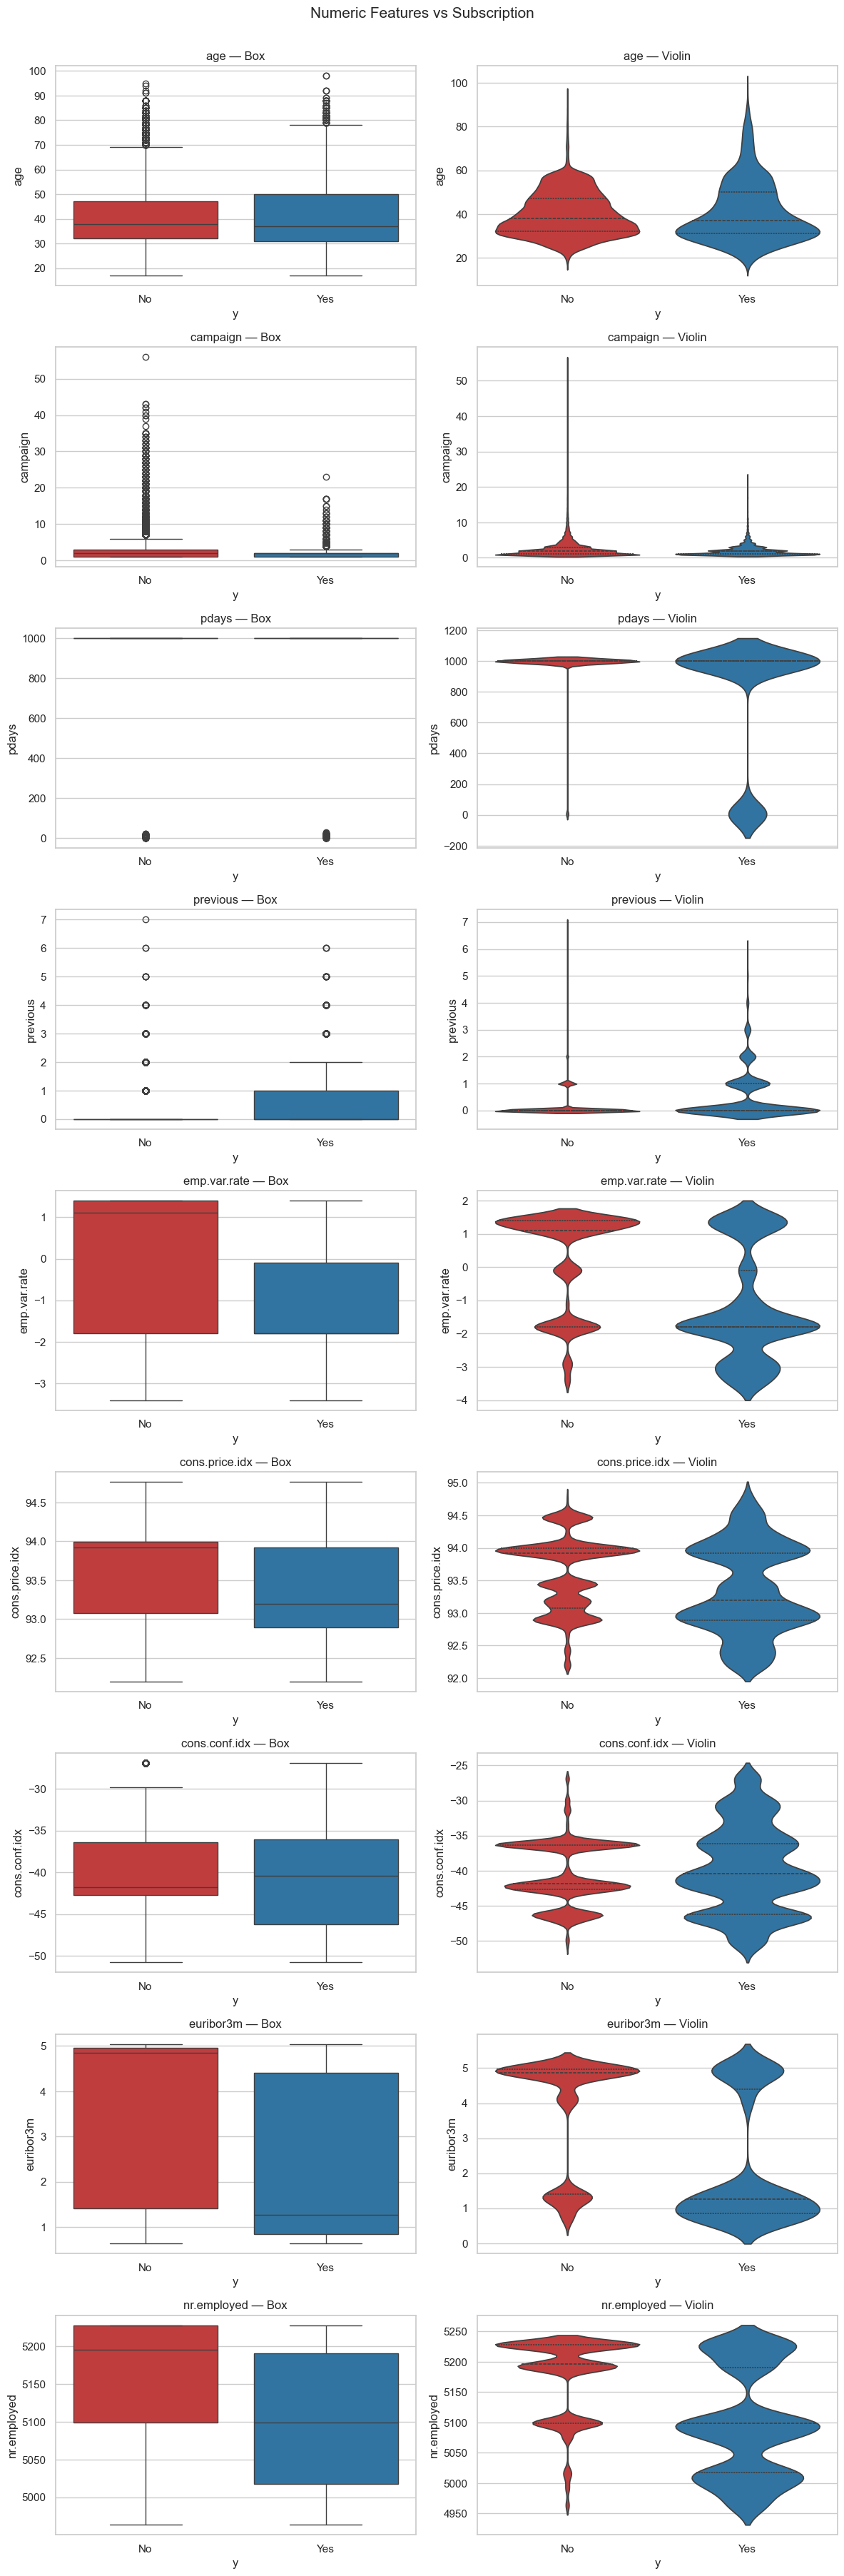

In [2]:
n = len(NUMERIC_RAW)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
pal = {"0": "#d62728", "1": "#1f77b4"}
df_plot = df.copy()
df_plot[TARGET_COL] = df_plot[TARGET_COL].astype(str)
for i, col in enumerate(NUMERIC_RAW):
    sns.boxplot(data=df_plot, x=TARGET_COL, y=col, ax=axes[i, 0], palette=pal)
    axes[i, 0].set_xticklabels(["No", "Yes"])
    axes[i, 0].set_title(f"{col} — Box")
    sns.violinplot(data=df_plot, x=TARGET_COL, y=col, ax=axes[i, 1], palette=pal, inner="quartile")
    axes[i, 1].set_xticklabels(["No", "Yes"])
    axes[i, 1].set_title(f"{col} — Violin")
plt.suptitle("Numeric Features vs Subscription", fontsize=15, y=1.002)
plt.tight_layout()
plt.show()


## 2 — Correlation Heatmap (Numeric Features)

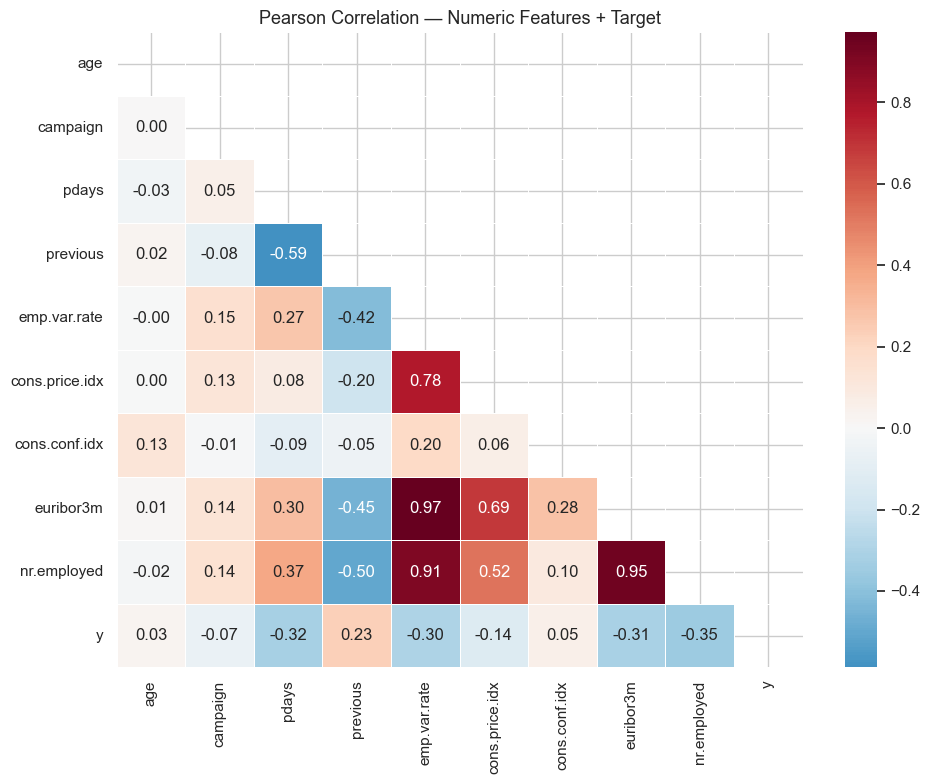


Top correlations with target y:


,r
nr.employed,-0.354678
pdays,-0.324914
euribor3m,-0.307771
emp.var.rate,-0.298334
previous,0.230181
cons.price.idx,-0.136211
campaign,-0.066357
cons.conf.idx,0.054878
age,0.030399


In [3]:
num_df = df[NUMERIC_RAW + [TARGET_COL]]
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Pearson Correlation — Numeric Features + Target", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop correlations with target y:")
display(corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False).to_frame("r"))

## 3 — Cramér's V Heatmap (Categorical vs Categorical)
Cramér's V measures association between two nominal variables (0 = no association, 1 = perfect).

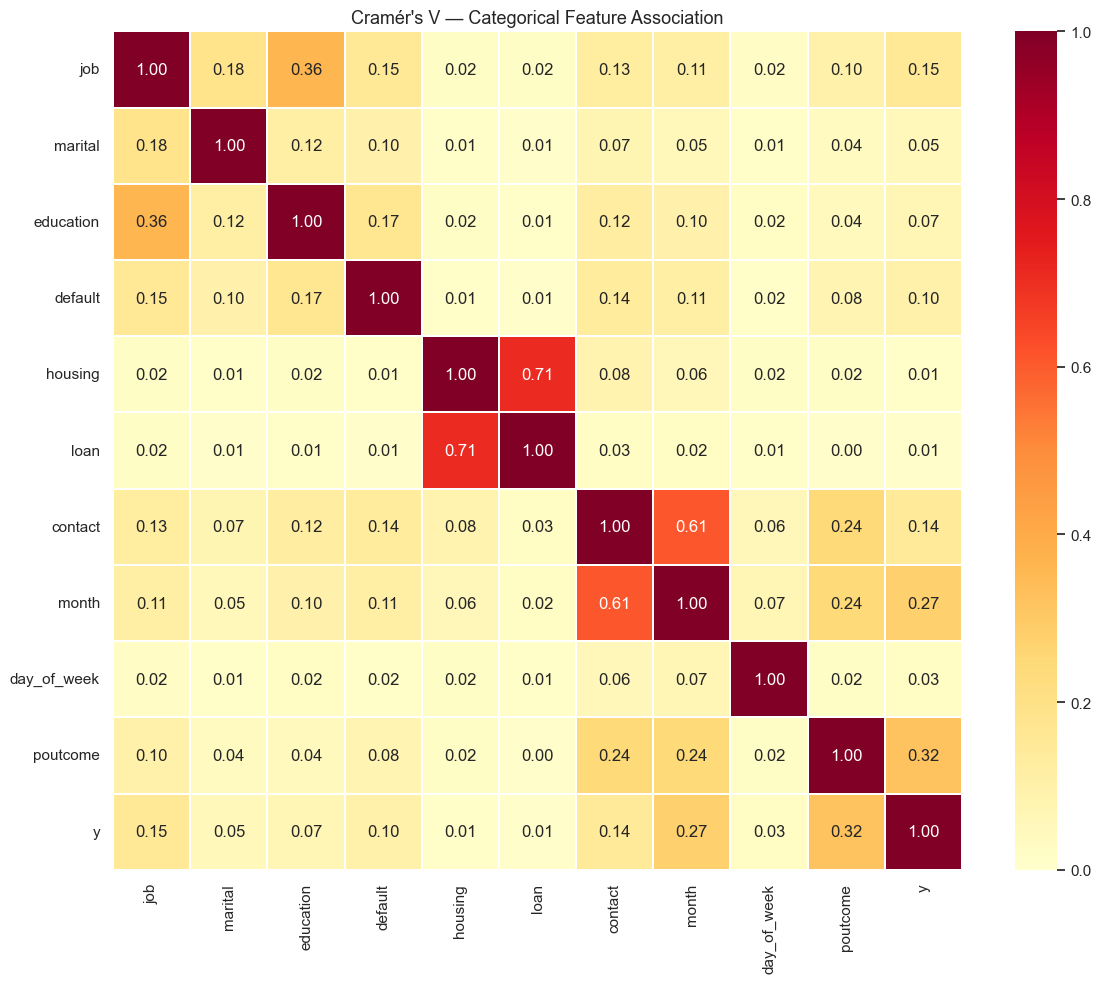


Cramér's V with target y:


,V
poutcome,0.320488
month,0.274395
job,0.152768
contact,0.144773
default,0.099354
education,0.068472
marital,0.054570
day_of_week,0.025195
housing,0.011748
loan,0.005154


In [4]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0.0

cat_cols_plus_target = CATEGORICAL_RAW + [TARGET_COL]
cat_df = df_raw.copy()
cat_df[TARGET_COL] = df_raw[TARGET_COL]

v_matrix = pd.DataFrame(index=cat_cols_plus_target, columns=cat_cols_plus_target, dtype=float)
for c1 in cat_cols_plus_target:
    for c2 in cat_cols_plus_target:
        v_matrix.loc[c1, c2] = cramers_v(cat_df[c1], cat_df[c2])

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(v_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            ax=ax, linewidths=0.3, vmin=0, vmax=1)
ax.set_title("Cramér's V — Categorical Feature Association", fontsize=13)
plt.tight_layout()
plt.show()

print("\nCramér's V with target y:")
display(v_matrix[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False).to_frame("V"))

## 4 — High-Conversion Segment Analysis
Which combinations of features produce the highest subscription rates?

sub_rate     n  sub_rate_pct
poutcome    contact  education                                        
success     cellular basic.4y             0.714286   119          71.4
                     professional.course  0.705882   170          70.6
                     university.degree    0.657895   494          65.8
                     high.school          0.624535   269          62.5
                     basic.9y             0.480769   104          48.1
failure     cellular unknown              0.254335   173          25.4
                     professional.course  0.176724   464          17.7
                     university.degree    0.163778  1154          16.4
                     basic.4y             0.144172   326          14.4
nonexistent cellular unknown              0.134289   767          13.4
                     university.degree    0.131831  7009          13.2
failure     cellular high.school          0.126074  1047          12.6
nonexistent cellular high.school          0.118604  4612          11.9
                     basic.4y             0.114436  1905          11.4
                     professional.course  0.107243  2844          10.7

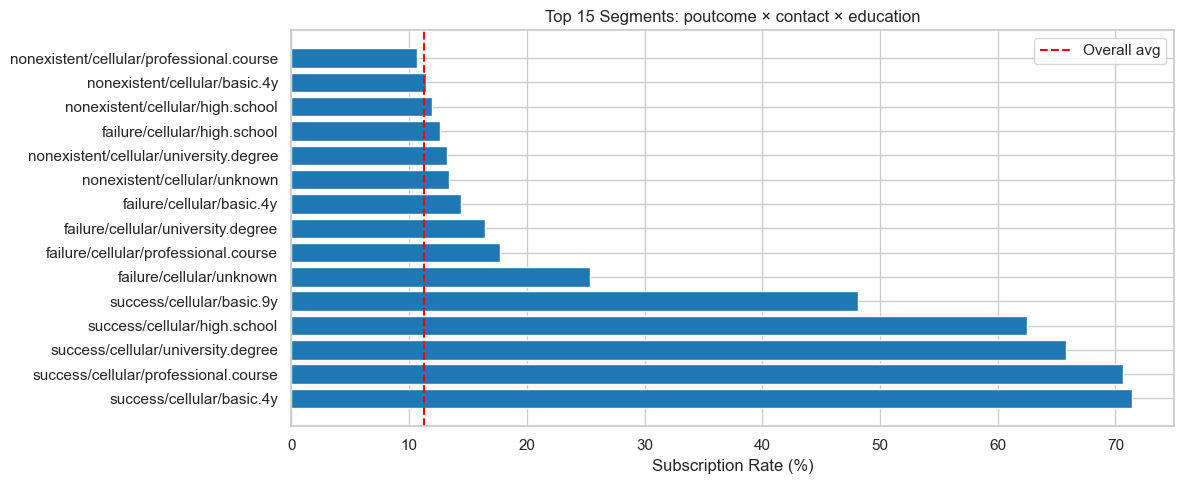

In [5]:
segments = (
    df.groupby(["poutcome", "contact", "education"], observed=True)[TARGET_COL]
    .agg(["mean", "count"])
    .rename(columns={"mean": "sub_rate", "count": "n"})
    .query("n >= 100")
    .sort_values("sub_rate", ascending=False)
    .head(15)
)
segments["sub_rate_pct"] = (segments["sub_rate"] * 100).round(1)
display(segments)

fig, ax = plt.subplots(figsize=(12, 5))
labels = [f"{i[0]}/{i[1]}/{i[2]}" for i in segments.index]
ax.barh(labels, segments["sub_rate_pct"], color="#1f77b4")
ax.axvline(df[TARGET_COL].mean() * 100, color="red", linestyle="--", label="Overall avg")
ax.set_xlabel("Subscription Rate (%)")
ax.set_title("Top 15 Segments: poutcome × contact × education")
ax.legend()
plt.tight_layout()
plt.show()